# ResNeXt & DenseNet : Pretrained vs Fine_tunning 

## config

In [2]:
import torch 
# 配置
config = {
    "data_dir" : './data',
    "device" : torch.device('cuda' if torch.cuda.is_available() else 'mps'
                if torch.backends.mps.is_available() else 'cpu'),
    "train_limit" : 300,
    "test_limit" : 30,
    "batch_size" : 128,
}

data_dir = config['data_dir']
device = config['device']
train_limit = config['train_limit']
test_limit = config['test_limit']
batch_size = config['batch_size']

## data_loader

In [3]:
from utils.data_loader import load_cifar10

In [4]:
# 导入DataSet、DataLoader
train_dataset, test_dataset, train_loader, test_loader = load_cifar10(data_dir=data_dir,
                                                                      batch_size=batch_size,
                                                                      train_limit=train_limit,
                                                                      test_limit=test_limit,
                                                                      random_seed=42)
print(f"训练集长度 : {len(train_dataset)}\n"
      f"测试集长度 : {len(test_dataset)}")

训练集长度 : 300
测试集长度 : 30


### show example

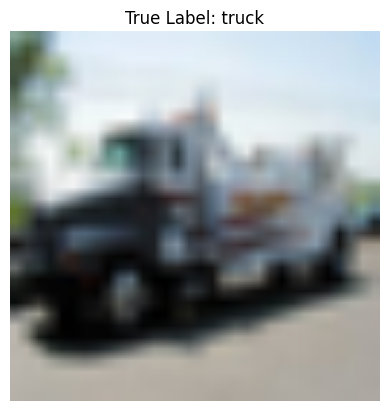

tensor([[[0.2025, 0.2025, 0.2025,  ..., 1.3201, 1.3201, 1.3201],
         [0.2025, 0.2025, 0.2025,  ..., 1.3201, 1.3201, 1.3201],
         [0.2025, 0.2025, 0.2025,  ..., 1.3201, 1.3201, 1.3201],
         ...,
         [1.1240, 1.1240, 1.1240,  ..., 0.9672, 0.9672, 0.9672],
         [1.1240, 1.1240, 1.1240,  ..., 0.9672, 0.9672, 0.9672],
         [1.1240, 1.1240, 1.1240,  ..., 0.9672, 0.9672, 0.9672]],

        [[0.8103, 0.8103, 0.8103,  ..., 1.8495, 1.8495, 1.8495],
         [0.8103, 0.8103, 0.8103,  ..., 1.8495, 1.8495, 1.8495],
         [0.8103, 0.8103, 0.8103,  ..., 1.8495, 1.8495, 1.8495],
         ...,
         [1.0456, 1.0456, 1.0456,  ..., 0.8691, 0.8691, 0.8691],
         [1.0456, 1.0456, 1.0456,  ..., 0.8691, 0.8691, 0.8691],
         [1.0456, 1.0456, 1.0456,  ..., 0.8691, 0.8691, 0.8691]],

        [[0.5554, 0.5554, 0.5554,  ..., 2.3201, 2.3201, 2.3201],
         [0.5554, 0.5554, 0.5554,  ..., 2.3201, 2.3201, 2.3201],
         [0.5554, 0.5554, 0.5554,  ..., 2.3201, 2.3201, 2.

In [5]:
import random
import matplotlib.pyplot as plt
from utils.predict import *
show_image(test_dataset)

## define net (pretrained & unfine_tunned)

In [6]:
import torchvision.models as models
model_d = models.densenet121(pretrained=True).to(device)

/Users/xueyicheng/miniconda3/envs/ch2/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/xueyicheng/miniconda3/envs/ch2/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
from torch import nn, optim
# 训练超参数设置
learning_rate = 1e-4
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model_d.parameters(), lr=learning_rate, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

## train

In [8]:
from utils.train import train_model

In [9]:
model_dd, history = train_model(
    model=model_d,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=1,
    use_amp=True,
    scheduler=scheduler,
    early_stop_patience=8,
    save_interval=4,
    print_freq=1,
    load_best_model=False,
    load_last_model=False,
)


/Users/xueyicheng/Documents/人工神经网络模型与算法/Chapter2/utils/train.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_amp)
/Users/xueyicheng/miniconda3/envs/ch2/lib/python3.12/site-packages/torch/amp/grad_scaler.py:132: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


save/DenseNet
Start training!
Device: mps, Model: DenseNet

 Epoch 1/1
------------------------------


Training:   0%|          | 0/3 [00:00<?, ?it/s]/Users/xueyicheng/Documents/人工神经网络模型与算法/Chapter2/utils/train.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
/Users/xueyicheng/miniconda3/envs/ch2/lib/python3.12/site-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
Training:   0%|          | 0/3 [01:00<?, ?it/s]

KeyboardInterrupt



In [9]:
predict(model_dd, test_dataset)

NameError: name 'model_dd' is not defined

In [17]:
import os
import json
# 创建保存目录
save_dir = "./save/history"
os.makedirs(save_dir, exist_ok=True)

# 保存 history 到 JSON 文件
history_path = os.path.join(save_dir, "training_history.json")
with open(history_path, 'w') as f:
    json.dump(history, f)

print(f"History saved to {history_path}")

./save/history


NameError: name 'history' is not defined